# 07 — Optimizers and the Complete End-to-End Training Loop (Manual NumPy)


> **Learning contract.** Every code cell is preceded by an explanation of what the code does, why the operation exists mathematically, what tensor/array shapes are expected, and what production or business failure it prevents. Run the notebooks in numerical order in a fresh Conda environment.


Training is repeated parameter estimation: sample a mini-batch, forward propagate, compute loss, backpropagate gradients, convert gradients into an optimizer update, then validate after the epoch. **Gradient is not the same thing as update.** SGD uses the current gradient directly; Momentum smooths updates with velocity; Adam combines moving averages of first and second moments.

The test split is deliberately absent from model-selection decisions in this notebook.


## Code walkthrough — complete Manual NumPy training pipeline
This is the core executable training code. Read it line by line. The training path shuffles mini-batches and updates parameters; the validation path performs forward-only evaluation. Metrics are collected every epoch and the trained artifact is persisted for later inference notebooks.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import urllib.request
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
ARTIFACT_DIR = ROOT / "artifacts"
DATA_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MNIST_PATH = DATA_DIR / "mnist.npz"
MNIST_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"


def load_official_mnist():
    if not MNIST_PATH.exists():
        print("Downloading official MNIST archive to", MNIST_PATH)
        urllib.request.urlretrieve(MNIST_URL, MNIST_PATH)
    with np.load(MNIST_PATH) as data:
        return (data["x_train"], data["y_train"], data["x_test"], data["y_test"])


def balanced_subset(x, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(10):
        candidates = np.flatnonzero(y == cls)
        selected.extend(rng.choice(candidates, size=per_class, replace=False))
    selected = np.asarray(selected)
    rng.shuffle(selected)
    return (x[selected], y[selected])


def prepare_splits():
    x_train_raw, y_train_raw, x_test_raw, y_test_raw = load_official_mnist()
    x_dev, y_dev = balanced_subset(x_train_raw, y_train_raw, per_class=600)
    x_test, y_test = balanced_subset(
        x_test_raw, y_test_raw, per_class=100, seed=SEED + 1
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x_dev, y_dev, test_size=1000, random_state=SEED, stratify=y_dev
    )

    def transform(x):
        return x.reshape(len(x), -1).astype("float32") / 255.0

    return (
        transform(x_train),
        y_train,
        transform(x_val),
        y_val,
        transform(x_test),
        y_test,
    )


rng = np.random.default_rng(SEED)
W1 = rng.normal(0, np.sqrt(2 / 784), size=(784, 64)).astype("float32")
b1 = np.zeros((1, 64), dtype="float32")
W2 = rng.normal(0, np.sqrt(2 / 64), size=(64, 10)).astype("float32")
b2 = np.zeros((1, 10), dtype="float32")


def relu(z):
    return np.maximum(z, 0)


def softmax(z):
    shifted = z - z.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    logits = a1 @ W2 + b2
    return (z1, a1, logits)


X_train, y_train, X_val, y_val, X_test, y_test = prepare_splits()
rng = np.random.default_rng(SEED)
W1 = rng.normal(0, np.sqrt(2 / 784), size=(784, 64)).astype("float32")
b1 = np.zeros((1, 64), dtype="float32")
W2 = rng.normal(0, np.sqrt(2 / 64), size=(64, 10)).astype("float32")
b2 = np.zeros((1, 10), dtype="float32")


def forward_params(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = np.maximum(z1, 0)
    logits = a1 @ W2 + b2
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    probs = exp / exp.sum(axis=1, keepdims=True)
    return (z1, a1, logits, probs)


def loss_and_grads(X, y, W1, b1, W2, b2):
    z1, a1, logits, probs = forward_params(X, W1, b1, W2, b2)
    n = len(X)
    loss = -np.log(probs[np.arange(n), y] + 1e-09).mean()
    dlogits = probs.copy()
    dlogits[np.arange(n), y] -= 1
    dlogits /= n
    dW2 = a1.T @ dlogits
    db2 = dlogits.sum(axis=0, keepdims=True)
    da1 = dlogits @ W2.T
    dz1 = da1 * (z1 > 0)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)
    return (loss, (dW1, db1, dW2, db2))


def accuracy(X, y):
    *_, probs = forward_params(X, W1, b1, W2, b2)
    return (probs.argmax(axis=1) == y).mean()


learning_rate = 0.08
batch_size = 128
epochs = 6
history = []
for epoch in range(1, epochs + 1):
    order = rng.permutation(len(X_train))
    batch_losses = []
    for start in range(0, len(order), batch_size):
        ids = order[start : start + batch_size]
        loss, grads = loss_and_grads(X_train[ids], y_train[ids], W1, b1, W2, b2)
        dW1, db1, dW2, db2 = grads
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        batch_losses.append(loss)
    train_acc = accuracy(X_train, y_train)
    val_acc = accuracy(X_val, y_val)
    history.append((np.mean(batch_losses), train_acc, val_acc))
    print(
        f"epoch={epoch} loss={np.mean(batch_losses):.4f} train_acc={train_acc:.4f} val_acc={val_acc:.4f}"
    )
np.savez(ARTIFACT_DIR / "mnist_manual_mlp.npz", W1=W1, b1=b1, W2=W2, b2=b2)

epoch=1 loss=1.4283 train_acc=0.6812 val_acc=0.6810
epoch=2 loss=0.7020 train_acc=0.8100 val_acc=0.8040
epoch=3 loss=0.5532 train_acc=0.6840 val_acc=0.6690
epoch=4 loss=0.4792 train_acc=0.8006 val_acc=0.7970
epoch=5 loss=0.4296 train_acc=0.8210 val_acc=0.8100
epoch=6 loss=0.3979 train_acc=0.8630 val_acc=0.8540


## Code walkthrough — visualize optimization instead of reading only the final accuracy
Loss should generally decrease while validation accuracy improves. A widening train/validation gap is an overfitting signal. Flat loss can indicate poor learning rate, bad initialization, insufficient capacity, preprocessing bugs or gradient problems.


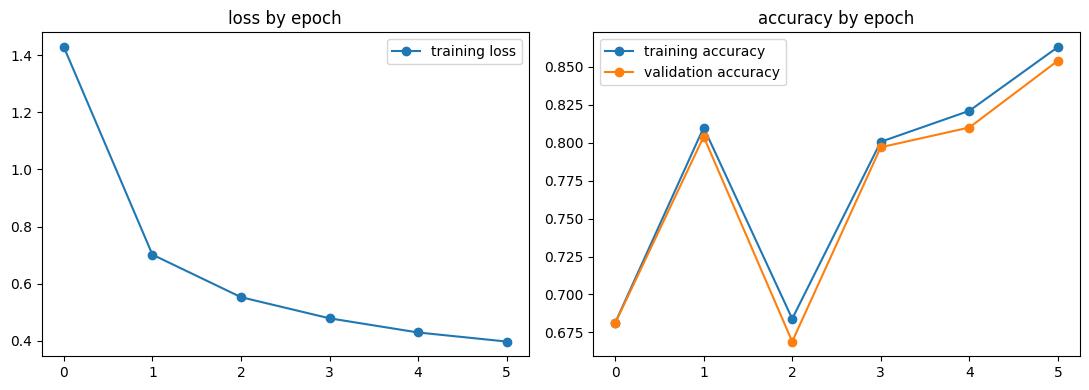

In [2]:
hist = np.asarray(history, dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist[:, 0], marker="o", label="training loss")
if hist.shape[1] == 4:
    axes[0].plot(hist[:, 2], marker="o", label="validation loss")
axes[0].legend()
axes[0].set_title("loss by epoch")
axes[1].plot(hist[:, 1], marker="o", label="training accuracy")
axes[1].plot(hist[:, -1], marker="o", label="validation accuracy")
axes[1].legend()
axes[1].set_title("accuracy by epoch")
plt.tight_layout()
plt.show()

## Production engineering checklist
A production training job also records code commit, dataset version, split IDs, hyperparameters, seed, environment lock, metrics, artifact checksum and run timestamp. The notebook teaches the mechanics; an MLOps system automates provenance and promotion.


### Interactive Plotly lab — clone + run locally

## Interactive 3D loss landscape and optimizer trajectories

> **GitHub vs local behavior.** GitHub keeps the committed static plots, tables, metrics and explanations visible. **Clone this branch, create `environment.yml`, open the notebook in VS Code/Jupyter, select the Conda kernel, and run the cell below for full Plotly interactivity**: hover, zoom, pan, 3D rotation, legend selection, sliders and animation.

Rotate the surface, hover exact loss values and compare learning rates. This deliberately low-dimensional landscape exposes how step size changes convergence, overshoot and oscillation.

**Production/business interpretation.** The interaction is an inspection instrument, not decoration: change or inspect a technical quantity and connect it to model behavior, operational risk or downstream decision quality.


In [3]:
import os
import numpy as np
import plotly.graph_objects as go

w_axis = np.linspace(-3, 4, 90); b_axis = np.linspace(-3, 2, 90); W, B = np.meshgrid(w_axis, b_axis); LOSS = (W - 1.5) ** 2 + 0.5 * (B + 0.5) ** 2
def path(lr, steps=18):
    w, b, rows = -2.5, 1.8, []
    for step in range(steps):
        loss = (w - 1.5) ** 2 + 0.5 * (b + 0.5) ** 2; rows.append((w, b, loss, step)); w -= lr * 2 * (w - 1.5); b -= lr * (b + 0.5)
    return rows
fig = go.Figure(data=[go.Surface(x=W, y=B, z=LOSS, opacity=0.72, colorscale="Viridis", hovertemplate="w=%{x:.2f}<br>b=%{y:.2f}<br>loss=%{z:.3f}<extra></extra>")])
for lr in [0.05, 0.2, 0.8]:
    rows = path(lr); fig.add_trace(go.Scatter3d(x=[r[0] for r in rows], y=[r[1] for r in rows], z=[r[2] for r in rows], mode="lines+markers", name=f"learning rate={lr}", text=[f"step={r[3]}" for r in rows], hovertemplate="%{text}<br>w=%{x:.3f}<br>b=%{y:.3f}<br>loss=%{z:.4f}<extra></extra>"))
fig.update_layout(title="Interactive loss landscape + gradient-descent trajectories", scene=dict(xaxis_title="weight w", yaxis_title="bias b", zaxis_title="loss"))
if os.getenv("GITHUB_ACTIONS") == "true":
    print("Interactive 3D optimization landscape built. Run locally to rotate and compare learning rates.")
else:
    fig.show(renderer="plotly_mimetype")


Interactive 3D optimization landscape built. Run locally to rotate and compare learning rates.
